In [1]:
import os
import sys
import yaml
import pandas as pd

current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

from functions.feature_selection import FeatureSelectionOrchestrator
from utils.plots import Pearson_correlation, Bar_plot


In [2]:
with open(os.path.join("../config/config.yaml"), "r") as f:
    config = yaml.safe_load(f)
        
with open(os.path.join( "../config/pipeline.yaml"), "r") as f:
    config_pipe = yaml.safe_load(f)  

In [3]:
pipeline_name = "Pipeline3"

In [4]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')

In [5]:
X_train.head()

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize,categorical_pipe__Pclass,categorical_pipe__Sex,categorical_pipe__Embarked,categorical_pipe__Title,categorical_pipe__Cabin_1p
331,0.198110,0.376343,0.812203,-0.243975,1.614136,-0.724310,-0.566021,-0.791063,1.303385
733,0.198110,-0.721837,0.812203,-0.243975,0.400551,-0.724310,-0.566021,-0.791063,-0.482394
382,0.198110,-0.721837,0.812203,-0.243975,-0.813034,-0.724310,-0.566021,-0.791063,-0.482394
704,0.198110,-0.721837,-1.231219,-0.243975,-0.813034,-0.724310,-0.566021,-0.791063,-0.482394
813,-3.007667,0.376343,-1.231219,4.098780,-0.813034,1.380624,-0.566021,1.067805,-0.482394


In [6]:
feature_selection = FeatureSelectionOrchestrator()

In [7]:
Anova = feature_selection.apply(
        "Anova",
        X_train.filter(like='numerical_pipe_con'),
        y_train)

c:\Users\gustavo\anaconda3\envs\mf_tf\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
mi = feature_selection.apply(
        "MutualInformationClassif", 
        X_train, 
        y_train)

c:\Users\gustavo\anaconda3\envs\mf_tf\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
corr = feature_selection.apply(
        "PearsonCorrelation", 
        X_train.filter(like='numerical'), 
        y_train)

In [10]:
mi

categorical_pipe__Title           0.163472
categorical_pipe__Sex             0.129592
categorical_pipe__Pclass          0.058689
categorical_pipe__Cabin_1p        0.046193
numerical_pipe_dis__IsAlone       0.024673
numerical_pipe_con__Fare          0.022551
numerical_pipe_dis__FamilySize    0.010618
numerical_pipe_con__Age           0.004429
categorical_pipe__Embarked        0.000000
Name: mutual information, dtype: float64

In [11]:
corr

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize
numerical_pipe_con__Age,1.000000,-0.025112,0.345122,-0.303624
numerical_pipe_con__Fare,-0.025112,1.000000,-0.428585,0.178895
numerical_pipe_dis__IsAlone,0.345122,-0.428585,1.000000,-0.300387
numerical_pipe_dis__FamilySize,-0.303624,0.178895,-0.300387,1.000000


# Decomposition analysis

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [13]:
X_train.shape

(712, 9)

In [14]:
pca = PCA()
pca.fit(X_train)

PCA()

In [15]:
transformed = pca.transform(X_train)

In [16]:
comp_variance=(pd.DataFrame.from_dict(
    {k:v for k, v in enumerate(pca.explained_variance_ratio_, 1)},
    orient='index',
    columns=['variance']
    )
               .reset_index()
               .rename(
                   columns={'index':'components'}))

In [17]:
comp_variance.assign(acumulado = lambda x: x['variance'].cumsum())

,components,variance,acumulado
0,1,0.316012,0.316012
1,2,0.219818,0.535830
2,3,0.149850,0.685680
3,4,0.105987,0.791667
4,5,0.076844,0.868511
5,6,0.064264,0.932775
6,7,0.041125,0.973900
7,8,0.021305,0.995205
8,9,0.004795,1.000000


<BarContainer object of 9 artists>

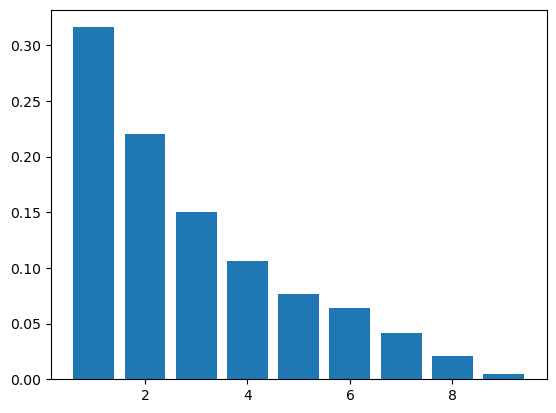

In [18]:
plt.bar(comp_variance['components'], comp_variance['variance'])